What certain functions do:
* fcn: single hidden layer MLP from in_size to out_size with a hidden_size layer; it is a class
* noisy_dataset: takes a prime and a fraction of train data as inputs (for what we care) and outputs the input and output train/test split; there is a possible noise level one can add, but we might not need that. we should implement this as a class I believe
* visualize_dataset: takes a 1D array and turns it into a 2D one and maps it; I guess it's just showing the sum of 2 integers
* train_one_epoch: performs one training step by backpropagation and returning the adjusted data and optionally the accuracy/loss; this is really what we've been doing too, the loss computation and all is not performed in the DNN or Encoder/Decoder module, but as a separate function
* calculate_gradients: computes and returns a dictionary of gradients for each weight in the MLP; importantly, it does not modify the weights, as there is no optimizer coupled to the MLP
* check_accuracy_grokking: takes an input and an output, runs the input through the MLP and compares the number of correct answers to the ones in the output (not sure how ordering works here, but maybe that is already built-in)
* calculate_ipr, calculate_gini: they check how randomly distributed an array is (in a Fourier basis; see Gromov paper for definition and usage of IPR measure)
* the hook library: it remembers individual inputs and output after each specified layer; this is good for extracting individual weights; also depending on the value of backward, it can also store the gradients flowing in or out of a layer

The functions above can make the workflow clearer, but maybe should be able to write them ourselves. Below is a schematic workflow:
* create data: input is a (p,p) matrix containing the pairs of integers; output is a (p,p) matrix containing the sum %p; manipulate these in terms of torch tensors and upload them to the cpu
* create a class for the MLP; we want a hidden layer and an output one. initialize weights correctly; use RELU for non-linear activation
* split data into training and test using the functions we used in the CNN (random split or smt)
* define loss function; use cross entropy
* add optimizer; use various: ADAMW, SGD etc
* create a training function; set the model on train, couple the optimizer to the model, compute losses and accuracy and store them in arrays
* create a forward function for test data; set the model on evaluate, rather than train, use the loss function, but don't couple the optimizer to it; again compute losses and accuracy and store them;
* run both of the above in parrallel for varying number of epochs
* plot the loss and accuracy and try to see where Grokking occurs

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import os
import sys
import copy
import pickle
import time
import math
import random
random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

from util.models import fcn
from util.datasets import visualize_dataset
from util.optimization import train_one_epoch_grokking, calculate_gradients, check_accuracy_grokking
from util.data_processing import calculate_ipr, calculate_gini, line, plot_linearmap
from util.hooks import Hook

dtype = torch.float32

############## Use GPU ##############
USE_GPU = False
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('CUDA')
else:
    device = torch.device('cpu')
print('using device:', device)

c:\anaconda3\envs\agq-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: cpu


c:\anaconda3\envs\agq-env\Lib\site-packages\timm\optim\optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)


In [2]:
def noisy_dataset(p:int, pair_seed:int, frac:float, noise_level:float, device, dtype, operation='addition', fixed_seed:bool=True):
    
    if operation.lower() not in ['addition', 'multiplication']:
        raise Exception('noisy_dataset function only makes Modular Addition and Multipllication datasets.')
    
    pairs = [(i,j) for i in range(p) for j in range(p)]
    X_og = torch.tensor(pairs)
    if operation.lower() == 'addition': Y_og = (( X_og[:,0]**1 + X_og[:,1]**1 )**1) % p
    elif operation.lower() == 'multiplication': Y_og = (( X_og[:,0]**1 * X_og[:,1]**1 )**1) % p
    X_og = F.one_hot(X_og, num_classes=p)
    
    #### Deterministic shuffle
    random.seed(pair_seed)
    orderlist = list(range(len(pairs)))
    random.shuffle(orderlist)
    pairs = [pairs[i] for i in orderlist]
    
    X = torch.tensor(pairs)
    
    if operation.lower() == 'addition': Y = (( X[:,0]**1 + X[:,1]**1 )**1) % p
    elif operation.lower() == 'multiplication': Y = (( X[:,0]**1 * X[:,1]**1 )**1) % p
    X = F.one_hot(X, num_classes=p)
    total_size = Y.shape[0]
    train_size = int(frac * total_size)
    test_size = total_size - train_size

    n_noise = int(noise_level * train_size)
    ids = torch.arange(n_noise)

    if fixed_seed == True:
        torch.random.manual_seed(0)
        random_labels = torch.randint(0, p, (n_noise,))
        labels_noise = copy.deepcopy(Y)
        labels_noise[:n_noise] = random_labels
    else:
        random_labels = torch.randint(0, p, (n_noise,))
        labels_noise = copy.deepcopy(Y)
        print(labels_noise.shape, random_labels.shape)
        # labels_noise[torch.randperm(train_size)[:n_noise]] = random_labels
        labels_noise[:n_noise] = copy.deepcopy(random_labels)
        # count = 0
        # for i in range(n_noise):
        #     if random_labels[i] == Y[i]:
        #         count += 1
        #         labels_noise[i] = torch.randint(0, p, (1,)).item()
        # print(f'# of changed corrupted labels = {count}')
        
    Y_noisy = copy.deepcopy(Y_og)
    for i in range(total_size):
        Y_noisy[orderlist[i]] = labels_noise[i]
    Y_noisy = Y_noisy.to(device=device, dtype=torch.long)
       
    X_og = X_og.to(device=device, dtype=dtype)
    Y_og = Y_og.to(device=device, dtype=torch.long)
    X_train = X[:train_size].to(device=device, dtype=dtype)
    Y_train = labels_noise[:train_size].to(device=device, dtype=torch.long)
    X_test = X[train_size:].to(device=device, dtype=dtype)
    Y_test = labels_noise[train_size:].to(device=device, dtype=torch.long)
    
    dataset_dict = {
        'X_train': X_train, 'Y_train': Y_train, 'X_test': X_test, 'Y_test': Y_test,
        'X_og': X_og, 'Y_og': Y_og, 'Y_noisy': Y_noisy, 'orderlist': orderlist,
        'p': p, 'data_frac': frac, 'noise_level': noise_level
    }
    
    return dataset_dict

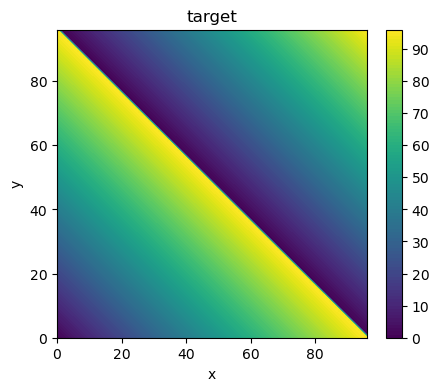

In [3]:
## Modular Arithmeitic Dataset

p = 97
data_frac = 0.5
noise_level = 0.0

dataset_dict = noisy_dataset(p, pair_seed, data_frac, noise_level, device, dtype)

visualize_dataset(dataset_dict)

## Training

In [4]:
epochs = 1000
data_every = 10
time = 10000000000
dp = 0

lr = 1e-3          # decent choices (N=500) : 5e1 for GD, 1e-2 for AdamW
wd = 15.0           # decent choices (N=500) : 0. for GD, [0.,8.] for AdamW
dp = 0.0

In [5]:
## Training

########################### Generatre dataset ###########################
p = 97
data_frac = 0.5
noise_level = 0.0
dataset_dict = noisy_dataset(p, pair_seed, data_frac, noise_level, device, dtype)
X_train = dataset_dict['X_train']; Y_train = dataset_dict['Y_train']
X_test = dataset_dict['X_test']; Y_test = dataset_dict['Y_test']
X_og = dataset_dict['X_og']; Y_og = dataset_dict['Y_og']
total_size = Y_og.shape[0]


########################### Initialize the model ###########################
N = 500
torch.manual_seed(1)
Student = fcn(2*p, N, p, dp)


########################### Data arrays ###########################
if_weight_norms = True
if_grad_norms = True
if_iprs = True
if_weights = True
if_grads = True
if_features = True

r = 2
chi_ipr = 0.5

data_epochs = np.arange(data_every, epochs+1, data_every)
if 1 not in data_epochs: data_epochs = np.insert(data_epochs, 0, 1)
if epochs not in data_epochs: data_epochs = np.append(data_epochs, epochs)

train_losses = np.empty(data_epochs.shape[0], float)
test_losses = np.empty(data_epochs.shape[0], float)
train_accs = np.empty(data_epochs.shape[0], float)
test_accs = np.empty(data_epochs.shape[0], float)

if if_weight_norms:
    weight_norms = {
        'U' : np.empty(data_epochs.shape[0], float),
        'V' : np.empty(data_epochs.shape[0], float),
        'W' : np.empty(data_epochs.shape[0], float)
    }
    
if if_grad_norms:
    grad_norms = {
        'U' : np.empty(data_epochs.shape[0], float),
        'V' : np.empty(data_epochs.shape[0], float), 
        'W' : np.empty(data_epochs.shape[0], float)
    }
    
if if_weights:
    weights = {
        'U':np.empty((data_epochs.shape[0], N, p), float), 
        'V':np.empty((data_epochs.shape[0], N, p), float), 
        'W':np.empty((data_epochs.shape[0], p, N), float)
    }
    weight_init = {
    'U': copy.deepcopy(Student.fc1.weight.detach().cpu().numpy())[:,:p],
    'V': copy.deepcopy(Student.fc1.weight.detach().cpu().numpy())[:,p:],
    'W': copy.deepcopy(Student.fc2.weight.detach().cpu().numpy()),
}
    
if if_grads:
    grads = {
        'U':np.empty((data_epochs.shape[0], N, p), float), 
        'V':np.empty((data_epochs.shape[0], N, p), float), 
        'W':np.empty((data_epochs.shape[0], p, N), float)
    }
if if_iprs:  
    iprs = {
        'U' : np.empty((data_epochs.shape[0], N), float),
        'V' : np.empty((data_epochs.shape[0], N), float),
        'W' : np.empty((data_epochs.shape[0], N), float),
        'U_grad' : np.empty((data_epochs.shape[0], N), float),
        'V_grad' : np.empty((data_epochs.shape[0], N), float),
        'W_grad' : np.empty((data_epochs.shape[0], N), float)
    }
    counts = {
        'U' : np.empty(data_epochs.shape[0], float),
        'V' : np.empty(data_epochs.shape[0], float),
        'W' : np.empty(data_epochs.shape[0], float), 
        'U_grad' : np.empty(data_epochs.shape[0], float),
        'V_grad' : np.empty(data_epochs.shape[0], float), 
        'W_grad' : np.empty(data_epochs.shape[0], float)
    }   # counts the number of rows with IPR greater than chi_ipr = 0.25 (default)
    gini_coefs = {
        'U' : np.empty((data_epochs.shape[0], N), float),
        'V' : np.empty((data_epochs.shape[0], N), float),
        'W' : np.empty((data_epochs.shape[0], N), float),
        'U_grad' : np.empty((data_epochs.shape[0], N), float),
        'V_grad' : np.empty((data_epochs.shape[0], N), float),
        'W_grad' : np.empty((data_epochs.shape[0], N), float)
    }
    
if if_features:    
    h1s_ordered = np.empty((data_epochs.shape[0], total_size, N), float)
    h2s_ordered = np.empty((data_epochs.shape[0], total_size, p), float)


########################### Copy the model for computing features ###########################
if if_features:
    Student_copy = fcn(2*p, N, p)
    Student_copy = Student_copy.to(device=device)
    hook1 = Hook(Student_copy.fc1)
    hook2 = Hook(Student_copy.fc2)


########################### Optimizer ###########################
optimizer = optim.AdamW(Student.parameters(), lr=lr,  weight_decay=wd, betas=(0.9, 0.98), eps=1e-08)
# optimizer = optim.SGD(Student.parameters(), lr=lr, weight_decay=wd, momentum=0.0)


########################### Training loop ###########################
i_d = 0
for epoch in range(1,epochs+1):
    if epoch in data_epochs:
        if_data = True
    else:
        if_data = False
        
    train_data = train_one_epoch_grokking(
        Student, optimizer, time, X_train, Y_train, X_test, Y_test,
        dtype, device, losstype='MSE', if_data=if_data, verbose=False
    )
    
    ## collect data
    if if_data:
        train_losses[i_d] = train_data['loss'][-1]
        test_losses[i_d] = train_data['val_loss'][-1]
        train_accs[i_d] = train_data['tr_acc'][-1]
        test_accs[i_d] = train_data['val_acc'][-1]

        if if_features:
            with torch.no_grad():
                Student_copy.load_state_dict(Student.state_dict())
                outputs_ordered = Student_copy(X_og.to(dtype=dtype))
                h1s_ordered[i_d] = hook1.output.detach().cpu().numpy()
                h2s_ordered[i_d] = hook2.output.detach().cpu().numpy()
        
        if if_weights or if_weight_norms or if_iprs:
            U = copy.deepcopy(Student.fc1.weight.data[:, :p]).detach().cpu().numpy()
            V = copy.deepcopy(Student.fc1.weight.data[:, p:]).detach().cpu().numpy()
            W = copy.deepcopy(Student.fc2.weight.data).detach().cpu().numpy()

        if if_grads or if_grad_norms or if_iprs:
            U_grad = train_data['grad1'][0][:,:p]
            V_grad = train_data['grad1'][0][:,p:]
            W_grad = train_data['grad2'][0]

        if if_weights:
            weights['U'][i_d] = U
            weights['V'][i_d] = V
            weights['W'][i_d] = W

        if if_grads:
            grads['U'][i_d] = U_grad
            grads['V'][i_d] = V_grad
            grads['W'][i_d] = W_grad

        if if_weight_norms:
            weight_norms['U'][i_d] = (np.abs(U)**2).sum()
            weight_norms['V'][i_d] = (np.abs(V)**2).sum()
            weight_norms['W'][i_d] = (np.abs(W)**2).sum()

        if if_grad_norms:
            grad_norms['U'][i_d] = (np.abs(U_grad)**2).sum() 
            grad_norms['V'][i_d] = (np.abs(V_grad)**2).sum()
            grad_norms['W'][i_d] = (np.abs(W_grad)**2).sum()

        if if_iprs:
            for k in range(N):
                iprs['U'][i_d, k] = calculate_ipr( np.absolute(np.fft.rfft(U[k])), r )
                iprs['V'][i_d, k]  = calculate_ipr( np.absolute( np.fft.rfft(V[k])), r )
                iprs['W'][i_d, k] = calculate_ipr( np.absolute( np.fft.rfft(W[:,k])), r )
                gini_coefs['U'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(U[k])))
                gini_coefs['V'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(V[k])))
                gini_coefs['W'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(W[:,k])))

                iprs['U_grad'][i_d, k] = calculate_ipr( np.absolute(np.fft.rfft(U_grad[k])), r )
                iprs['V_grad'][i_d, k]  = calculate_ipr( np.absolute( np.fft.rfft(V_grad[k])), r )
                iprs['W_grad'][i_d, k] = calculate_ipr( np.absolute( np.fft.rfft(W_grad[:,k])), r )
                gini_coefs['U_grad'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(U_grad[k])))
                gini_coefs['V_grad'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(V_grad[k])))
                gini_coefs['W_grad'][i_d, k] = calculate_gini( np.absolute(np.fft.rfft(W_grad[:,k])))

        print(f'epoch epochs:{epoch} \t train_loss:{train_losses[i_d]} \t test_loss:{test_losses[i_d]} \t train_acc:{train_accs[i_d]} \t test_acc:{test_accs[i_d]}')
        
        i_d += 1


########################### IPR row/column counts ###########################
if if_iprs:
    counts['U'] = (iprs['U'] > chi_ipr).sum(axis=1)
    counts['V'] = (iprs['V'] > chi_ipr).sum(axis=1)
    counts['W'] = (iprs['W'] > chi_ipr).sum(axis=1)
    counts['U_grad'] = (iprs['U_grad'] > chi_ipr).sum(axis=1)
    counts['V_grad'] = (iprs['V_grad'] > chi_ipr).sum(axis=1)
    counts['W_grad'] = (iprs['W_grad'] > chi_ipr).sum(axis=1)


########################### Print training data at the end of training ###########################
print('')       
print('final train loss : {:}'.format(train_losses[-1]))
print('final test loss : {:}'.format(test_losses[-1]))
print('final train acc : {:}'.format(train_accs[-1]))
print('final test acc : {:}'.format(test_accs[-1]))

epoch epochs:1 	 train_loss:0.01042346004396677 	 test_loss:0.01036135945469141 	 train_acc:0.011054421768707483 	 test_acc:0.009351753453772583
epoch epochs:10 	 train_loss:0.010147864930331707 	 test_loss:0.010253531858325005 	 train_acc:0.06568877551020408 	 test_acc:0.005738575982996812
epoch epochs:20 	 train_loss:0.01008657831698656 	 test_loss:0.010254318825900555 	 train_acc:0.24489795918367346 	 test_acc:0.001487778958554729
epoch epochs:30 	 train_loss:0.01005823165178299 	 test_loss:0.01025661826133728 	 train_acc:0.4721513605442177 	 test_acc:0.0004250797024442083
epoch epochs:40 	 train_loss:0.010035465471446514 	 test_loss:0.010258103720843792 	 train_acc:0.6207482993197279 	 test_acc:0.00021253985122210415
epoch epochs:50 	 train_loss:0.010010535828769207 	 test_loss:0.010260024107992649 	 train_acc:0.7332057823129252 	 test_acc:0.00021253985122210415
epoch epochs:60 	 train_loss:0.009979477152228355 	 test_loss:0.010262499563395977 	 train_acc:0.7988945578231292 	 test_